--- DATASET LOADED SUCCESSFULLY ---


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Categorical Columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Training Data: (36168, 42)
Testing Data: (9043, 42)

--- MODEL TRAINED ---
Test Accuracy: 0.8959

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7952
           1       0.65      0.30      0.41      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.64      0.68      9043
weighted avg       0.88      0.90      0.88      9043



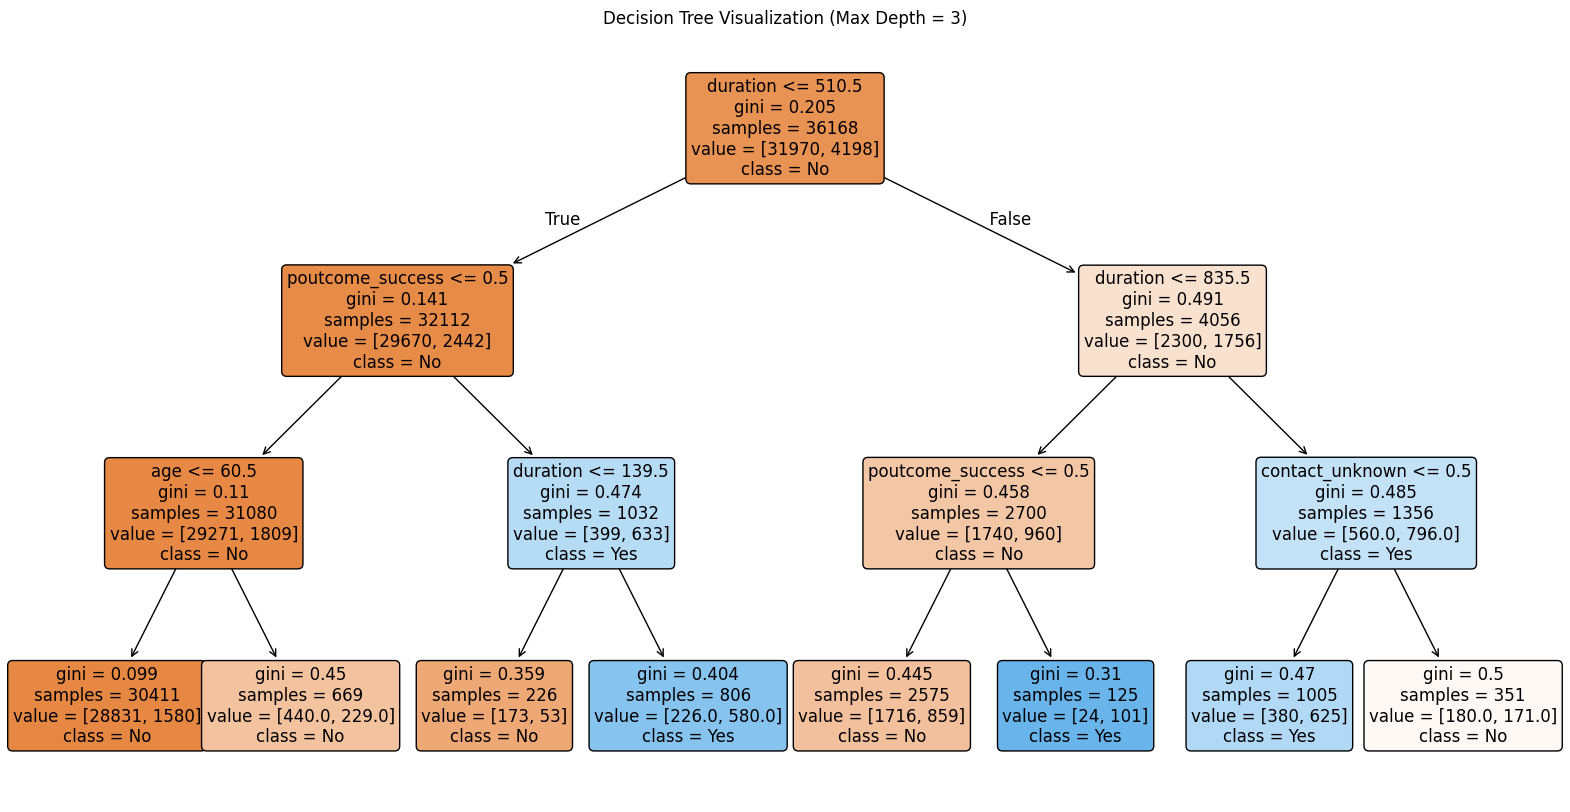


--- TOP PREDICTIVE FEATURES ---
duration            0.581637
poutcome_success    0.354849
age                 0.058509
contact_unknown     0.005005
balance             0.000000
dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests, zipfile, io
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# 1. Load Dataset (OFFICIAL UCI SOURCE - BULLETPROOF)
# We download the zip directly from the University of California Irvine
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"

print(f"Downloading data from: {url}")
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))

# The zip contains 'bank-full.csv' (the complete dataset)
# We use sep=';' because the official file uses semicolons, not commas
df = pd.read_csv(z.open('bank-full.csv'), sep=';')

print("--- DATASET LOADED SUCCESSFULLY ---")
display(df.head())

# 2. Data Preprocessing
# Target variable is 'y' (yes/no) in the official dataset
target_col = 'y'

# Convert Target to Binary (yes=1, no=0)
df[target_col] = df[target_col].map({'yes': 1, 'no': 0})

# Identify Categorical Columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical Columns: {list(categorical_cols)}")

# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 3. Split Data
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining Data: {X_train.shape}")
print(f"Testing Data: {X_test.shape}")

# 4. Train Decision Tree
# We limit max_depth=3 to keep the tree readable
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)
print("\n--- MODEL TRAINED ---")

# 5. Evaluation
y_pred = model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

# 6. Visualize the Tree
plt.figure(figsize=(20, 10))
plot_tree(model,
          feature_names=X.columns,
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("Decision Tree Visualization (Max Depth = 3)")
plt.show()

# 7. Extract Rules
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n--- TOP PREDICTIVE FEATURES ---")
print(importances.head(5))